In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# CIFAR-10 classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

Using device: cpu


In [2]:
# Notice: No Grayscale! We keep the 3 color channels (RGB)
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.CIFAR10(root="../data", train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root="../data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print("CIFAR-10 data loaded successfully.")

CIFAR-10 data loaded successfully.


In [3]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32 * 32 * 3, 256),  # <-- 3072 inputs for color
    nn.ReLU(),
    nn.Linear(256, 10)            # 10 classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)


In [4]:
epochs = 10
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}")

Epoch 2: train_loss=1.6906
Epoch 4: train_loss=1.5792
Epoch 6: train_loss=1.5188
Epoch 8: train_loss=1.4777
Epoch 10: train_loss=1.4455


In [5]:
torch.save(model.state_dict(), "../reports/color_model.pth")
print("Color model saved successfully!")

Color model saved successfully!


In [5]:
custom_transform = transforms.Compose([
    transforms.Resize((32, 32)), # Resize to match model input
    transforms.ToTensor()        # Keep RGB channels (no Grayscale!)
])

In [6]:
def predict_custom_color_image(image_path):
    # 1. Load image
    img = Image.open(image_path).convert("RGB") 
    
    # 2. Preprocess
    img_tensor = custom_transform(img)
    img_tensor = img_tensor.unsqueeze(0).to(device) # Add batch dimension
    
    # 3. Predict
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = logits.argmax(dim=1).item()
        confidence = probs.max().item()
        
    # 4. Display
    plt.imshow(img)
    plt.title(f"Predicted: {class_names[pred_idx]} | Confidence: {confidence:.2f}")
    plt.axis("off")
    plt.show()
    
    return class_names[pred_idx], confidence

print("Prediction function ready for color images!")

Prediction function ready for color images!


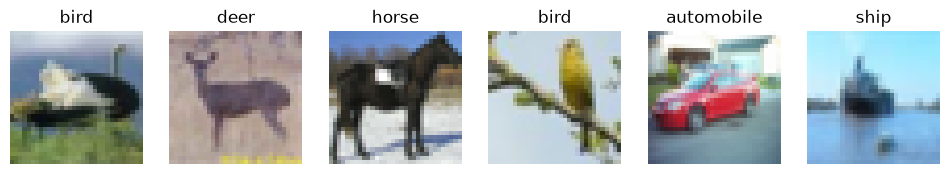

In [7]:
import matplotlib.pyplot as plt

# 1. Get one batch of training data
images, labels = next(iter(train_loader))

# 2. Set up a plot with 1 row and 6 columns
fig, axes = plt.subplots(1, 6, figsize=(12, 2))

# 3. Loop through the first 6 images and display them
for ax, img, label in zip(axes, images[:6], labels[:6]):
    # PyTorch shape is [C, H, W]. Matplotlib needs [H, W, C]. 
    # .permute(1, 2, 0) rearranges the dimensions.
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(class_names[label])
    ax.axis("off")

plt.show()

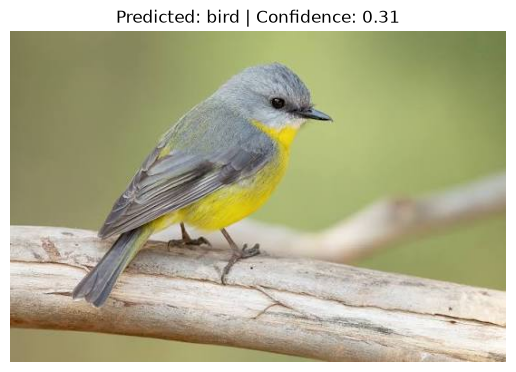

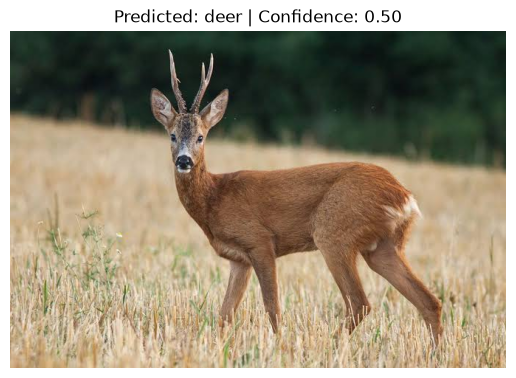

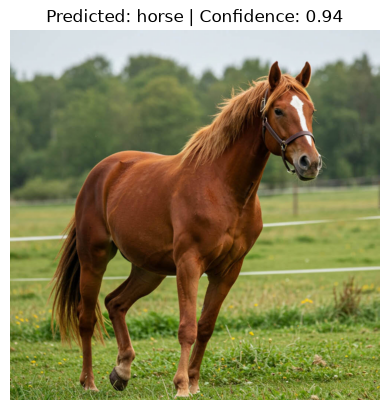

('horse', 0.9387110471725464)

In [8]:
# Test the downloaded animal images in the COLOR notebook
predict_custom_color_image("bird.jpg")
predict_custom_color_image("deer.jpg")
predict_custom_color_image("horse.jpg")

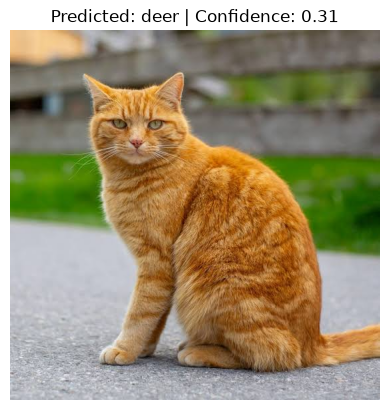

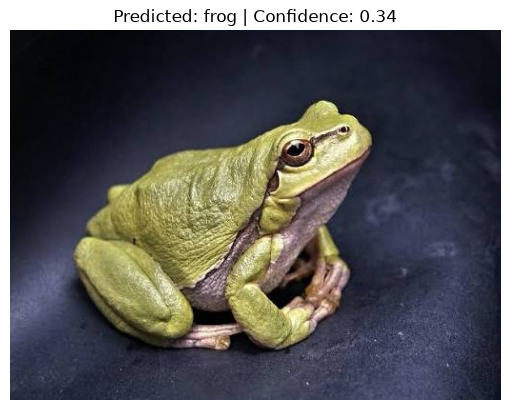

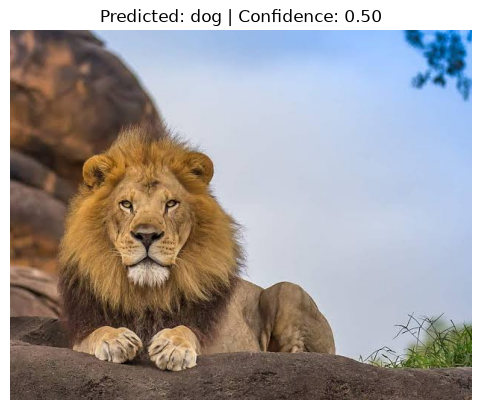

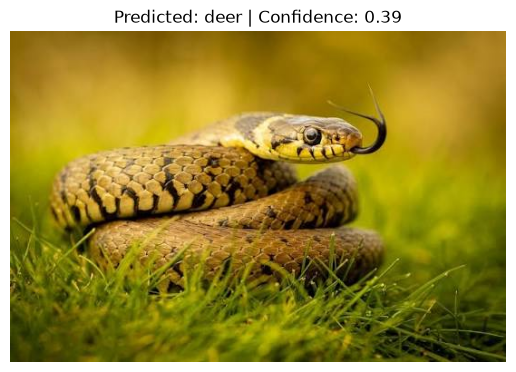

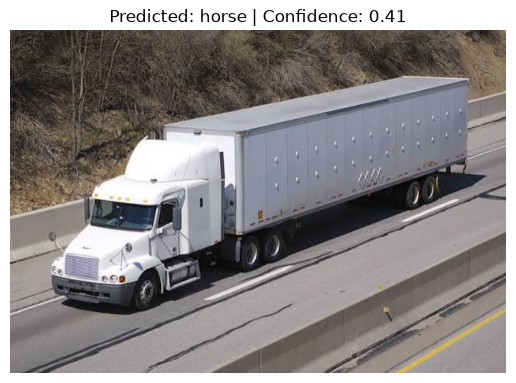

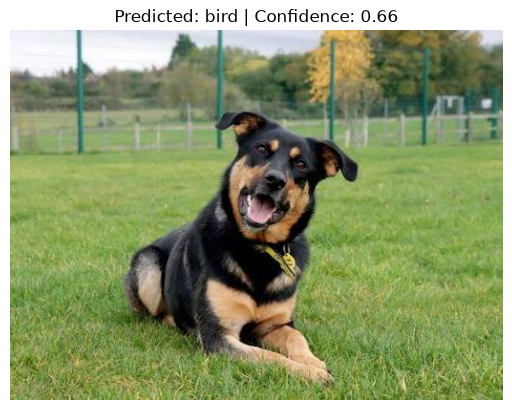

('bird', 0.6626831889152527)

In [9]:
# Test the downloaded animal images in the COLOR notebook
predict_custom_color_image("Cat.jpg")
predict_custom_color_image("frog.jpg")
predict_custom_color_image("lion.jpg")
predict_custom_color_image("snake.jpg")
predict_custom_color_image("Truck.jpg")
predict_custom_color_image("Dog.jpg")

## Real-World Inference Test: CIFAR-10 MLP ##

**Observation**

I tested the trained color MLP model on six custom, high-resolution images downloaded from the internet. The results were poor, with only 1 out of 6 images classified correctly, and even that prediction had a very low confidence score.

 	 	
1. Cat(Image)    Cat(True) 	    Deer(Label Predicted) 		0.31(Label Confidence Correct) ❌
2. Frog(Image)   Frog(True)     Frog(Label Predicted) 		0.34(Label Confidence Correct) ✅
3. Lion(Image) 	 Lion(True)     Dog(Label Predicted) 		0.50(Label Confidence Correct) ❌
4. Snake(Image)  Snake(True)    Deer(Label Predicted) 		0.39(Label Confidence Correct) ❌
5. Truck(Image)  Truck(True)    Horse(Label Predicted) 		0.41(Label Confidence Correct) ❌
6. Dog(Image) 	 Dog(True) 	    Bird(Label Predicted) 		0.66(Label Confidence Correct) ❌

**Analysis**

*The failure of this MLP on real-world images is expected and highlights fundamental limitations in the architecture and the training data:*

1. **Lack of Spatial Awareness:** The MLP flattens the 32x32x3 image into a 1D array of 3072 numbers. It completely destroys spatial information. It does not see edges, shapes, or textures—only raw pixel intensities. To the model, a Lion and a Dog are just fuzzy blobs of similar-colored pixels.
2. **Extreme Resolution Reduction:** Real-world photos are much larger than 32x32 pixels. Squashing a high-resolution photo of a snake into a 32x32 grid destroys almost all its defining features (scales, head shape, pattern), leaving just a blurry green/brown blob that might resemble a deer.
3. **Domain Shift & Background Noise:** CIFAR-10 images are perfectly centered with minimal background. My downloaded images have complex backgrounds (grass, trees, sky). The MLP treats background pixels with the same importance as the object, causing it to be confused by grass (predicting deer/horse) instead of focusing on the animal.
4. **Low Confidence Scores:** Even when it guessed correctly (Frog), the confidence was only 0.34, indicating the model was essentially "guessing" among a few similar-looking classes.

### Conclusion ###

	This experiment proves that an MLP is not robust for real-world computer vision. While it can achieve reasonable accuracy on the structured, low-resolution CIFAR-10 test set, it completely fails when exposed to real-world domain shifts (different backgrounds, lighting, angles, and resolutions).

	To classify real-world images successfully, we must use Convolutional Neural Networks (CNNs), which preserve spatial structure, extract meaningful features (edges, shapes), and are invariant to translation and scale.